In [23]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Baseline models
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree         import DecisionTreeClassifier
from sklearn.neighbors    import KNeighborsClassifier
from sklearn.naive_bayes  import GaussianNB
from sklearn.ensemble     import RandomForestClassifier, GradientBoostingClassifier
from xgboost              import XGBClassifier
from lightgbm             import LGBMClassifier

## 1. Label Map

In [3]:
LABEL_MAP = {
    0: "Drought",
    1: "Earthquake",
    2: "Epidemic",
    3: "Extreme Temp",
    4: "Flood",
    5: "Landslide",
    6: "Storm",
    7: "Wildfire",
}
TARGET_NAMES = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]

## 2. Load CLeaned

In [4]:
data = pd.read_excel('../data/cleaned/cleaned_disaster_dataset.xlsx')
data.head()

,event_duration_log_norm,magnitude_missing,subregion_Australia and New Zealand,subregion_Central Asia,subregion_Eastern Asia,subregion_Eastern Europe,subregion_Latin America and the Caribbean,subregion_Melanesia,subregion_Micronesia,subregion_Northern Africa,...,country_Viet Nam,country_Wallis and Futuna Islands,country_Yemen,country_Yemen Arab Republic,country_Yugoslavia,country_Zambia,country_Zimbabwe,total_deaths_normalized,magnitude_scaled,disaster_type_encoded
0,0.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.575230,0.329509,6
1,0.0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0.377358,0.000000,4
2,0.0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0.227058,0.000000,2
3,0.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.327216,0.117902,1
4,0.0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.928246,0.000000,0


## 3. Define X Y

In [5]:
X = data.drop("disaster_type_encoded", axis=1).copy()
y = data["disaster_type_encoded"]

# LightGBM cannot fit feature names with punctuation or non-ASCII symbols.
def make_model_safe_columns(columns):
    safe_columns = (
        pd.Series(columns, dtype="string")
        .str.replace(r"[^A-Za-z0-9_]+", "_", regex=True)
        .str.strip("_")
    )
    safe_columns = safe_columns.mask(safe_columns == "", "feature")

    counts = {}
    unique_columns = []
    for column in safe_columns:
        base = str(column)
        count = counts.get(base, 0)
        unique_columns.append(base if count == 0 else f"{base}_{count}")
        counts[base] = count + 1
    return unique_columns

original_feature_names = X.columns.tolist()
X.columns = make_model_safe_columns(original_feature_names)
renamed_features = sum(
    old != new for old, new in zip(original_feature_names, X.columns)
)
print(f"Renamed {renamed_features} feature columns for model compatibility.")

for code, name in LABEL_MAP.items():
    n = (y == code).sum()
    print(f"  {code} {name:<20} {n:>5}  ({n/len(y)*100:.1f}%)")

  0 Drought                803  (4.6%)
  1 Earthquake            1651  (9.4%)
  2 Epidemic              1622  (9.3%)
  3 Extreme Temp           730  (4.2%)
  4 Flood                 6183  (35.4%)
  5 Landslide              918  (5.3%)
  6 Storm                 5053  (28.9%)
  7 Wildfire               514  (2.9%)


In [13]:
X.columns = X.columns.str.replace(r'[\[\]\{\}\:\,"]', '_', regex=True)

In [6]:
print(data.columns.tolist())

['event_duration_log_norm', 'magnitude_missing', 'subregion_Australia and New Zealand', 'subregion_Central Asia', 'subregion_Eastern Asia', 'subregion_Eastern Europe', 'subregion_Latin America and the Caribbean', 'subregion_Melanesia', 'subregion_Micronesia', 'subregion_Northern Africa', 'subregion_Northern America', 'subregion_Northern Europe', 'subregion_Polynesia', 'subregion_South-eastern Asia', 'subregion_Southern Asia', 'subregion_Southern Europe', 'subregion_Sub-Saharan Africa', 'subregion_Western Asia', 'subregion_Western Europe', 'region_Africa', 'region_Americas', 'region_Asia', 'region_Europe', 'region_Oceania', 'magnitude_scale_Km2', 'magnitude_scale_Kph', 'magnitude_scale_Moment Magnitude', 'magnitude_scale_Morbidity rate', 'magnitude_scale_Vaccinated', 'magnitude_scale_°C', 'country_Afghanistan', 'country_Albania', 'country_Algeria', 'country_American Samoa', 'country_Angola', 'country_Anguilla', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'coun

## 4. Split Train 80/20 Test
`stratify=y` ensures every class lands at the same proportion in both splits. 

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Verify stratification held
print("\nClass proportions — train vs test (should match):")
for code, name in LABEL_MAP.items():
    tr = (y_train == code).sum() / len(y_train) * 100
    te = (y_test  == code).sum() / len(y_test)  * 100
    print(f"  {name:<20}  train {tr:.1f}%   test {te:.1f}%")

Train size: (13979, 262)
Test size: (3495, 262)

Class proportions — train vs test (should match):
  Drought               train 4.6%   test 4.6%
  Earthquake            train 9.4%   test 9.4%
  Epidemic              train 9.3%   test 9.3%
  Extreme Temp          train 4.2%   test 4.2%
  Flood                 train 35.4%   test 35.4%
  Landslide             train 5.3%   test 5.3%
  Storm                 train 28.9%   test 28.9%
  Wildfire              train 2.9%   test 2.9%


## 5. Cross-Validation Setup

`StratifiedKFold` preserves class proportions in every fold — essential with a 12× imbalance.  
CV is run **on the training set only**; the test set remains unseen.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = [
    "accuracy",
    "f1_macro", "f1_weighted",
    "precision_macro", "precision_weighted",
    "recall_macro", "recall_weighted",
]

## 8. Model

6 models from simplest to most powerful:

| Model | Type | Notes |
|-------|------|-------|
|SVM (RBF) | Radial Basis Function | Best at non-linear boundaries; slower on large data |
| Logistic Regression | Linear | Fast, interpretable |
| Decision Tree | Non-linear | Single tree, prone to overfit |
| Random Forest | Ensemble (bagging) | Strong baseline |
| XGBoost | Ensemble (boosting) | Usually top performer | -->
| LightGBM | Ensemble (boosting) | Faster than XGBoost on large data |

All non-dummy models use `class_weight='balanced'` to handle the 12× imbalance.

In [16]:
models = {
    "Logistic Regression": LogisticRegression(
                               max_iter=1000,
                               class_weight="balanced",
                               random_state=42),
    "Decision Tree"      : DecisionTreeClassifier(
                               class_weight="balanced",
                               random_state=42),
    "Random Forest"      : RandomForestClassifier(
                               n_estimators=200,
                               class_weight="balanced",
                               random_state=42,
                               n_jobs=-1),
    "XGBoost"            : XGBClassifier(
                               n_estimators=200,
                               eval_metric="mlogloss",
                               random_state=42,
                               n_jobs=-1,
                              verbosity=0),
    "LightGBM"           : LGBMClassifier(
                               n_estimators=200,
                               class_weight="balanced",
                               random_state=42,
                               n_jobs=-1,
                               verbose=-1),
    "SVM (RBF)"          : SVC(
                               kernel="rbf",
                               class_weight="balanced",
                               random_state=42,
                               cache_size=500),

}

## 9. Cross-Validation Results (Train Set Only)

> **Why F1-Macro?**  
> Accuracy is misleading here — a model that always predicts Flood scores 35%.  
> F1-Macro averages the F1 score across all 8 classes equally, penalising 
> the model for ignoring rare classes like Wildfire (2.9%).

In [20]:
cv_summary = []

for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv, scoring=SCORING,
        return_train_score=False, n_jobs=-1
    )
    cv_summary.append({
        "Model"            : name,
        "Accuracy"         : scores["test_accuracy"].mean(),
        "Accuracy ±"       : scores["test_accuracy"].std(),
        "F1 Macro"         : scores["test_f1_macro"].mean(),
        "F1 Macro ±"       : scores["test_f1_macro"].std(),
        "F1 Weighted"      : scores["test_f1_weighted"].mean(),
        "F1 Weighted ±"    : scores["test_f1_weighted"].std(),
        "Precision Macro"  : scores["test_precision_macro"].mean(),
        "Precision Macro ±": scores["test_precision_macro"].std(),
        "Recall Macro"     : scores["test_recall_macro"].mean(),
        "Recall Macro ±"   : scores["test_recall_macro"].std(),
    })
    print(f"{name:<22}  "
          f"Acc={scores['test_accuracy'].mean():.4f}±{scores['test_accuracy'].std():.4f}  "
          f"F1-Mac={scores['test_f1_macro'].mean():.4f}±{scores['test_f1_macro'].std():.4f}  "
          f"F1-Wtd={scores['test_f1_weighted'].mean():.4f}±{scores['test_f1_weighted'].std():.4f}  "
          f"Prec-Mac={scores['test_precision_macro'].mean():.4f}±{scores['test_precision_macro'].std():.4f}  "
          f"Rec-Mac={scores['test_recall_macro'].mean():.4f}±{scores['test_recall_macro'].std():.4f}")

cv_df = pd.DataFrame(cv_summary).set_index("Model")

Logistic Regression     Acc=0.7762±0.0056  F1-Mac=0.7400±0.0041  F1-Wtd=0.7908±0.0061  Prec-Mac=0.7309±0.0028  Rec-Mac=0.8365±0.0065
Decision Tree           Acc=0.8658±0.0036  F1-Mac=0.7885±0.0026  F1-Wtd=0.8718±0.0022  Prec-Mac=0.7718±0.0033  Rec-Mac=0.8156±0.0033
Random Forest           Acc=0.8855±0.0051  F1-Mac=0.7971±0.0028  F1-Wtd=0.8856±0.0038  Prec-Mac=0.7950±0.0059  Rec-Mac=0.8006±0.0064
XGBoost                 Acc=0.9044±0.0033  F1-Mac=0.8080±0.0057  F1-Wtd=0.8977±0.0034  Prec-Mac=0.8434±0.0057  Rec-Mac=0.7864±0.0061
LightGBM                Acc=0.8691±0.0019  F1-Mac=0.8049±0.0029  F1-Wtd=0.8772±0.0020  Prec-Mac=0.7830±0.0027  Rec-Mac=0.8447±0.0042
SVM (RBF)               Acc=0.7775±0.0082  F1-Mac=0.7401±0.0059  F1-Wtd=0.7931±0.0089  Prec-Mac=0.7319±0.0040  Rec-Mac=0.8319±0.0040


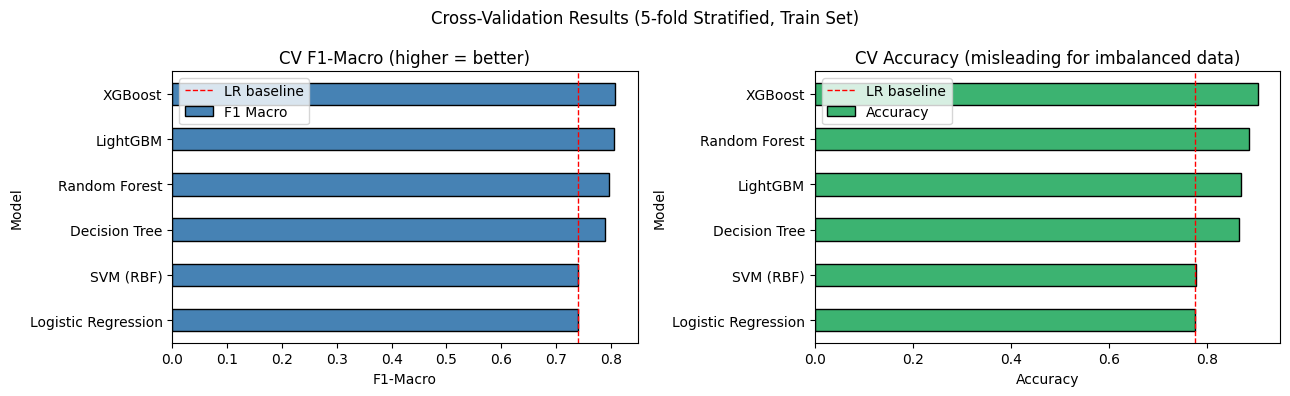

In [22]:
# Visual comparison — CV F1-Macro vs Accuracy
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cv_df["F1 Macro"].sort_values().plot(
    kind="barh", ax=axes[0], color="steelblue", edgecolor="black"
)
axes[0].set_title("CV F1-Macro (higher = better)")
axes[0].set_xlabel("F1-Macro")
axes[0].axvline(cv_df.loc["Logistic Regression", "F1 Macro"], color="red",
                linestyle="--", linewidth=1, label="LR baseline")
axes[0].legend()

cv_df["Accuracy"].sort_values().plot(
    kind="barh", ax=axes[1], color="mediumseagreen", edgecolor="black"
)
axes[1].set_title("CV Accuracy (misleading for imbalanced data)")
axes[1].set_xlabel("Accuracy")
axes[1].axvline(cv_df.loc["Logistic Regression", "Accuracy"], color="red",
                linestyle="--", linewidth=1, label="LR baseline")
axes[1].legend()

plt.suptitle("Cross-Validation Results (5-fold Stratified, Train Set)", fontsize=12)
plt.tight_layout()
plt.show()

## 10. Test Set Evaluation (Held-Out 20%)

Each model is refit on the full training set, then evaluated once on the test set.

In [ ]:
test_summary = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    test_summary.append({
        "Model"      : name,
        "Accuracy"   : accuracy_score(y_test, y_pred),
        "F1 Macro"   : f1_score(y_test, y_pred, average="macro"),
        "F1 Weighted": f1_score(y_test, y_pred, average="weighted"),
        "Precision"  : precision_score(y_test, y_pred, average="macro"),
        "Recall"     : recall_score(y_test, y_pred, average="macro")
    })

test_df = pd.DataFrame(test_summary).set_index("Model")
test_df.sort_values("F1 Macro", ascending=False).round(4)


,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
Model,,,,,
XGBoost,0.9041,0.8046,0.8966,0.8417,0.7824
LightGBM,0.8627,0.7992,0.8728,0.7769,0.8449
Random Forest,0.8764,0.7863,0.8776,0.7821,0.7915
Decision Tree,0.8615,0.7816,0.8678,0.7667,0.8044
SVM (RBF),0.7740,0.7356,0.7905,0.7279,0.8293
Logistic Regression,0.7717,0.7345,0.7873,0.7267,0.8304


In [25]:
# Per-class classification report for every model
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=TARGET_NAMES))

  Logistic Regression
              precision    recall  f1-score   support

     Drought       0.32      0.62      0.42       160
  Earthquake       1.00      1.00      1.00       330
    Epidemic       1.00      1.00      1.00       324
Extreme Temp       1.00      1.00      1.00       146
       Flood       0.91      0.45      0.60      1237
   Landslide       0.35      0.82      0.49       184
       Storm       1.00      1.00      1.00      1011
    Wildfire       0.24      0.76      0.36       103

    accuracy                           0.77      3495
   macro avg       0.73      0.83      0.73      3495
weighted avg       0.88      0.77      0.79      3495

  Decision Tree
              precision    recall  f1-score   support

     Drought       0.58      0.75      0.66       160
  Earthquake       1.00      1.00      1.00       330
    Epidemic       1.00      1.00      1.00       324
Extreme Temp       1.00      1.00      1.00       146
       Flood       0.86      0.77      0

## 11. Confusion Matrices

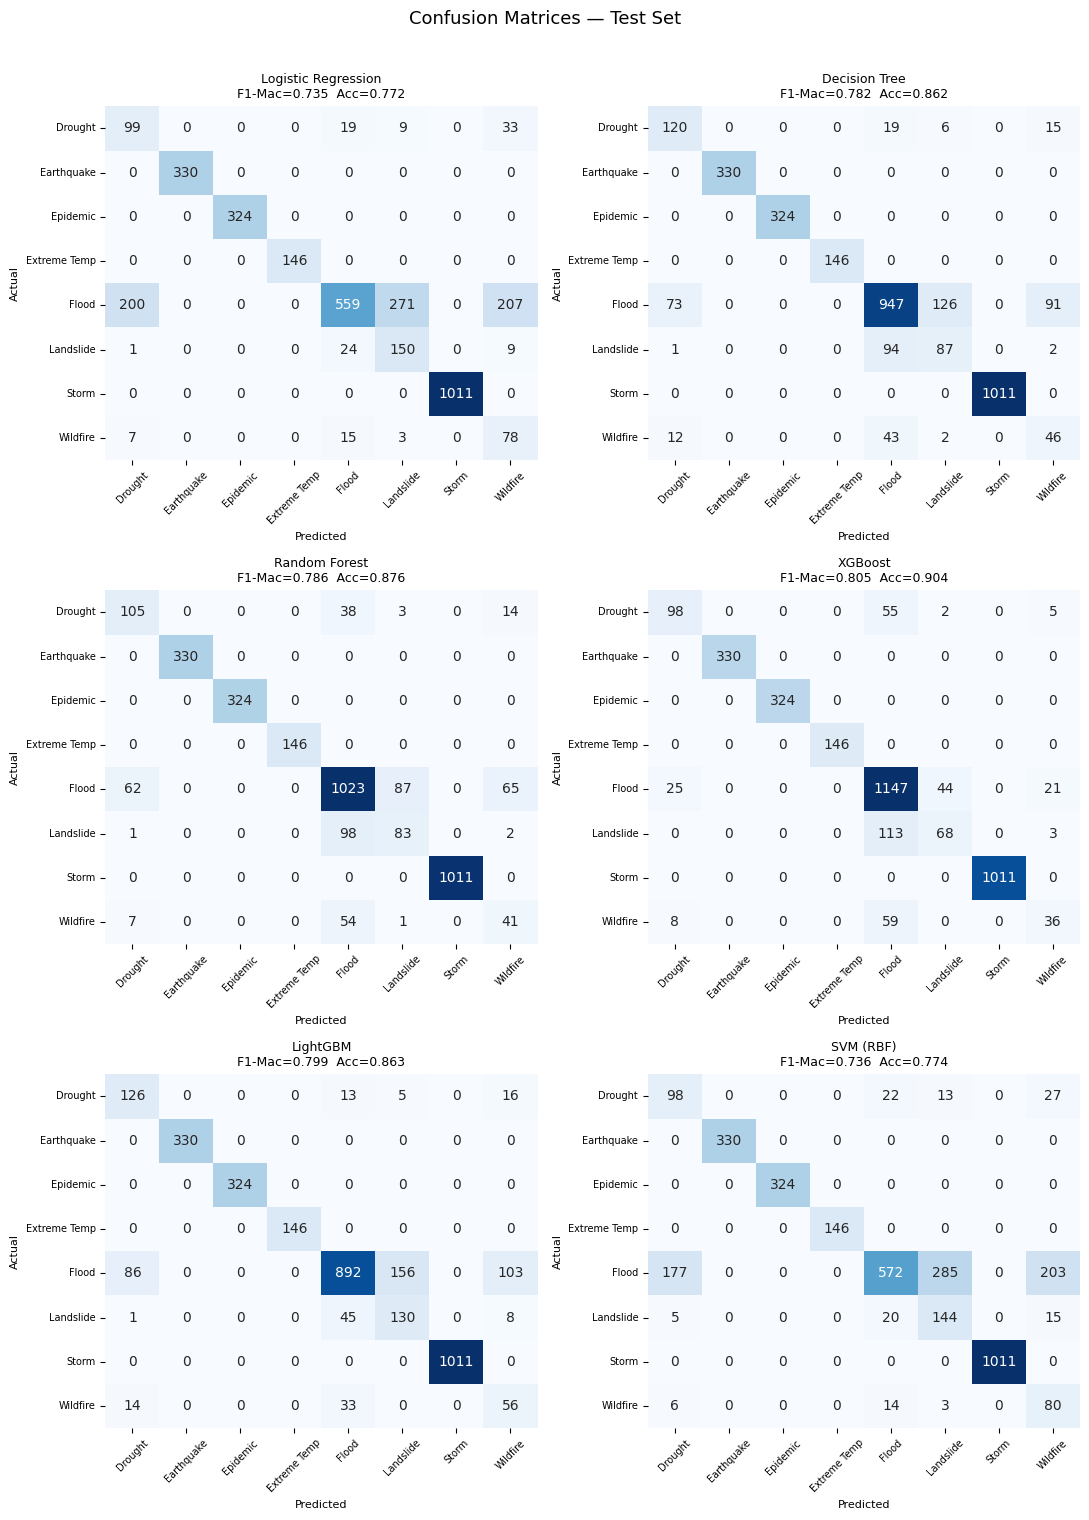

In [26]:
n_models = len(models)              # 9 models → 3×3 grid
ncols    = 2
nrows    = (n_models + ncols - 1) // ncols   # auto-compute rows

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.5, nrows * 5))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax,
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
                cmap="Blues", cbar=False)
    f1  = f1_score(y_test, y_pred, average="macro")
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f"{name}\nF1-Mac={f1:.3f}  Acc={acc:.3f}", fontsize=9)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual", fontsize=8)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", rotation=0,  labelsize=7)

# Hide unused subplots
for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle("Confusion Matrices — Test Set", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 12. Feature Importance (Tree-Based Models)

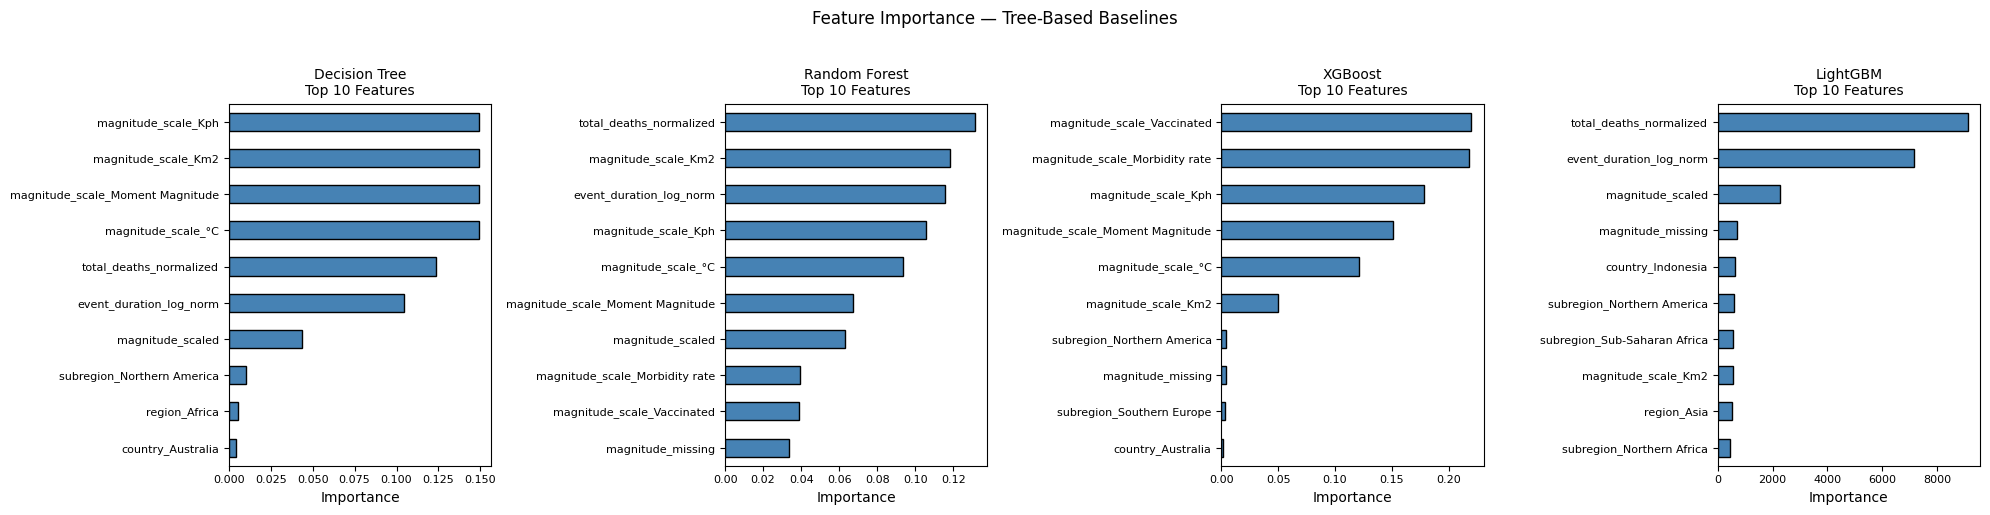

In [28]:
tree_models = {
    "Decision Tree": models["Decision Tree"],
    "Random Forest": models["Random Forest"],
    "XGBoost"      : models["XGBoost"],
    "LightGBM" :models["LightGBM"]
}

fig, axes = plt.subplots(1, len(tree_models), figsize=(20, 5))

for ax, (name, model) in zip(axes, tree_models.items()):
    imp = pd.Series(model.feature_importances_, index=X.columns)
    imp.nlargest(10).sort_values().plot(
        kind="barh", ax=ax, color="steelblue", edgecolor="black"
    )
    ax.set_title(f"{name}\nTop 10 Features", fontsize=10)
    ax.set_xlabel("Importance")
    ax.tick_params(labelsize=8)

plt.suptitle("Feature Importance — Tree-Based Baselines", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 13. Comparison 

In [29]:
print("CV vs Test F1-Macro comparison:")
print(f"{'Model':<22}  {'CV F1-Mac':>10}  {'Test F1-Mac':>11}")
print("-" * 48)
for name in models:
    cv_f1  = cv_df.loc[name, "F1 Macro"]
    tst_f1 = test_df.loc[name, "F1 Macro"]
    gap    = tst_f1 - cv_f1
    flag   = "  ⚠ overfit" if gap < -0.05 else ""
    print(f"{name:<22}  {cv_f1:>10.4f}  {tst_f1:>11.4f}{flag}")

print("\nBest model by Test F1-Macro:")
best = test_df["F1 Macro"].idxmax()
print(f"  → {best}  (F1-Macro = {test_df.loc[best, 'F1 Macro']:.4f})")

print("""
Next steps:
  1. Investigate Wildfire & Drought — lowest per-class F1 across all models
  2. Consider removing total_deaths / total_damage if this is a pre-event predictor
  3. Hyperparameter tuning on the best 1-2 models (GridSearchCV / Optuna)
  4. Try SMOTE oversampling on minority classes if F1-Macro on rare classes stays low
""")

CV vs Test F1-Macro comparison:
Model                    CV F1-Mac  Test F1-Mac
------------------------------------------------
Logistic Regression         0.7400       0.7345
Decision Tree               0.7885       0.7816
Random Forest               0.7971       0.7863
XGBoost                     0.8080       0.8046
LightGBM                    0.8049       0.7992
SVM (RBF)                   0.7401       0.7356

Best model by Test F1-Macro:
  → XGBoost  (F1-Macro = 0.8046)

Next steps:
  1. Investigate Wildfire & Drought — lowest per-class F1 across all models
  2. Consider removing total_deaths / total_damage if this is a pre-event predictor
  3. Hyperparameter tuning on the best 1-2 models (GridSearchCV / Optuna)
  4. Try SMOTE oversampling on minority classes if F1-Macro on rare classes stays low

